In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
df = pd.read_csv("inventory_data.csv")
df['date'] = pd.to_datetime(df['date'])

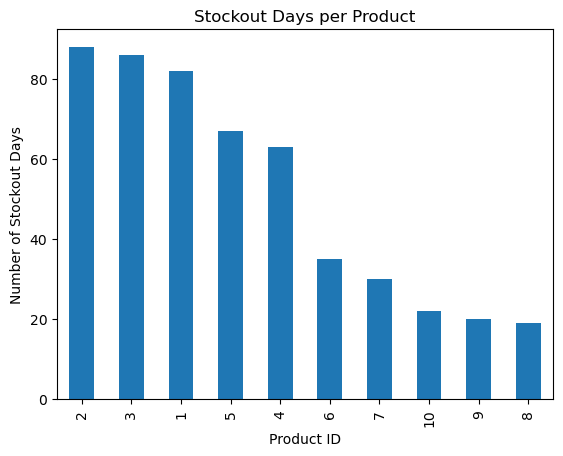

In [20]:
stockouts = df[df['stock_level'] == 0] \
    .groupby('product_id') \
    .size() \
    .sort_values(ascending=False)

plt.figure()
stockouts.plot(kind='bar')
plt.title("Stockout Days per Product")
plt.xlabel("Product ID")
plt.ylabel("Number of Stockout Days")
plt.show()

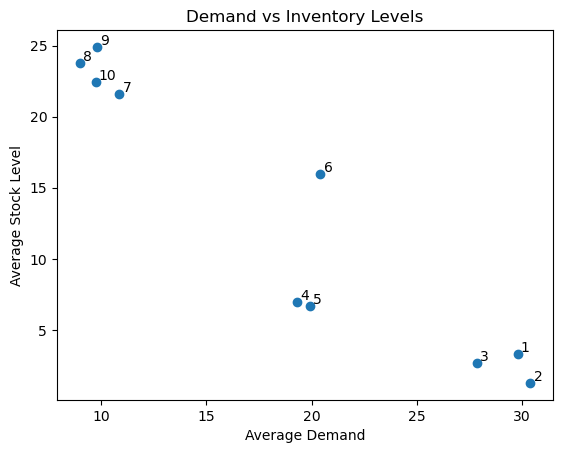

In [70]:
summary = df.groupby('product_id').agg({
    'demand': 'mean',
    'stock_level': 'mean'
})

plt.figure()
plt.scatter(summary['demand'], summary['stock_level'])
plt.xlabel("Average Demand")
plt.ylabel("Average Stock Level")
plt.title("Demand vs Inventory Levels")

for product_id, row in summary.iterrows():
    plt.annotate(product_id, (row['demand'], row['stock_level']), xytext=(row['demand']+0.15, row['stock_level']+0.15))

plt.show()

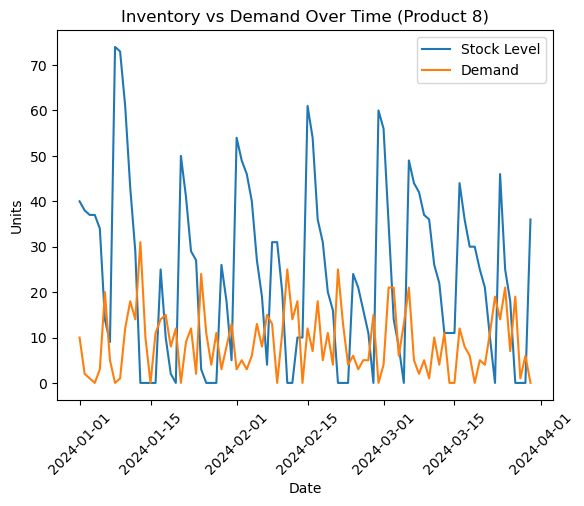

In [42]:
product_id = 8  # change this

product_df = df[df['product_id'] == product_id]

plt.figure()
plt.plot(product_df['date'], product_df['stock_level'], label='Stock Level')
plt.plot(product_df['date'], product_df['demand'], label='Demand')

plt.title(f"Inventory vs Demand Over Time (Product {product_id})")
plt.xlabel("Date")
plt.ylabel("Units")
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [26]:
summary = df.groupby('product_id').agg({
    'demand': ['mean', 'std'],
    'lead_time': 'max'
})

summary.columns = ['avg_demand', 'std_demand', 'lead_time']

# Safety stock (simple version)
summary['safety_stock'] = summary['std_demand'] * 2

# Reorder point
summary['reorder_point'] = (
    summary['avg_demand'] * summary['lead_time']
    + summary['safety_stock']
)

print(summary)

            avg_demand  std_demand  lead_time  safety_stock  reorder_point
product_id                                                                
1            29.788889    8.789031          5     17.578062     166.522506
2            30.400000    7.868012          7     15.736025     228.536025
3            27.844444    9.149091          2     18.298182      73.987071
4            19.311111    6.149165          5     12.298331     108.853886
5            19.922222    6.848649          5     13.697298     113.308409
6            20.422222    4.637361          7      9.274722     152.230278
7            10.866667    7.507599          3     15.015198      47.615198
8             8.977778    7.137459          2     14.274918      32.230474
9             9.811111    5.297645          9     10.595290      98.895290
10            9.744444    4.872673          9      9.745347      97.445347


In [38]:
stockouts = df[df['stock_level'] == 0].groupby('product_id').size()

summary['stockout_days'] = stockouts
summary['stockout_days'] = summary['stockout_days'].fillna(0)

# sort by worst offenders
summary = summary.sort_values(by='stockout_days', ascending=False)

print(summary)

            avg_demand  std_demand  lead_time  safety_stock  reorder_point  \
product_id                                                                   
2            30.400000    7.868012          7     15.736025     228.536025   
3            27.844444    9.149091          2     18.298182      73.987071   
1            29.788889    8.789031          5     17.578062     166.522506   
5            19.922222    6.848649          5     13.697298     113.308409   
4            19.311111    6.149165          5     12.298331     108.853886   
6            20.422222    4.637361          7      9.274722     152.230278   
7            10.866667    7.507599          3     15.015198      47.615198   
10            9.744444    4.872673          9      9.745347      97.445347   
9             9.811111    5.297645          9     10.595290      98.895290   
8             8.977778    7.137459          2     14.274918      32.230474   

            stockout_days  
product_id                 
2      